<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

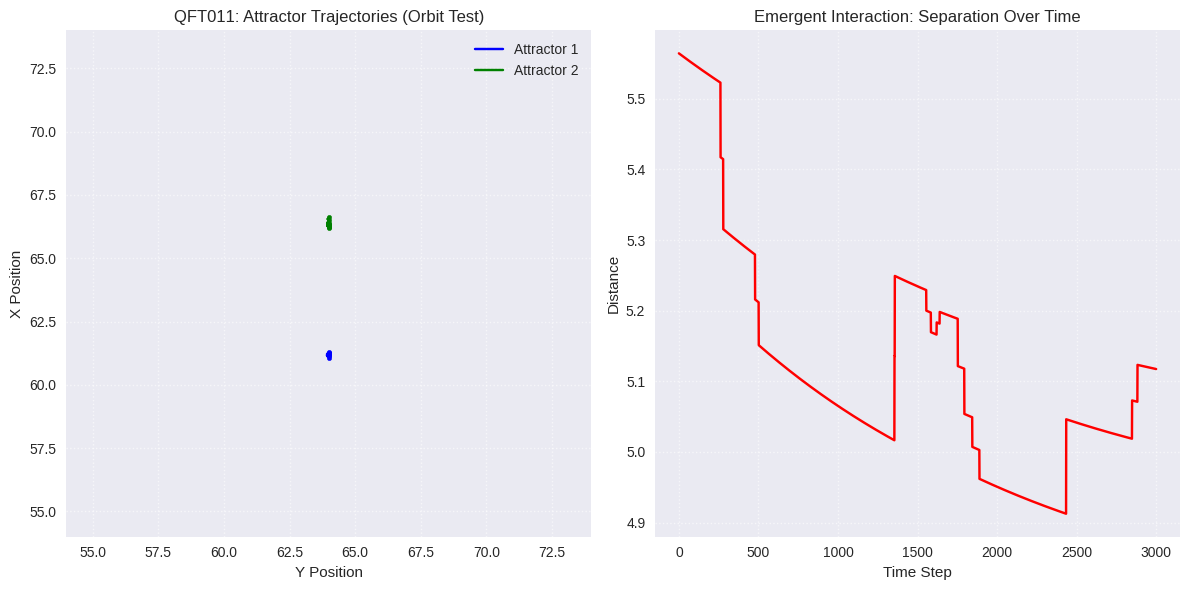

In [1]:
# QFT011: Stable Emergent Orbit Test — Fixed Version
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass

# Parameters
N_grid = 128
T = 3000
dt = 0.01
delta = 0.10
gamma = 0.08
kappa = 0.05
v = 0.05  # transverse velocity

# Grid setup
x = np.arange(N_grid)
y = np.arange(N_grid)
X, Y = np.meshgrid(x, y, indexing='ij')

# Initial positions
sep = 6
x1, y1 = N_grid//2 - sep//2, N_grid//2
x2, y2 = N_grid//2 + sep//2, N_grid//2

# Gaussian attractor with phase velocity
def gaussian_with_velocity(x0, y0, vx, vy, width=2.0, amp=0.01):
    phase = vx * X + vy * Y
    envelope = amp * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * width**2))
    return envelope * np.exp(1j * phase)

# Initialize field
psi1 = gaussian_with_velocity(x1, y1, 0, +v)
psi2 = gaussian_with_velocity(x2, y2, 0, -v)
psi = (psi1 + psi2).astype(np.complex128)

# FFT kernel
kx = np.fft.fftfreq(N_grid) * (2 * np.pi)
ky = np.fft.fftfreq(N_grid) * (2 * np.pi)
KX, KY = np.meshgrid(kx, ky, indexing='ij')
laplacian_kernel = -(KX**2 + KY**2)
implicit_denominator = 1 - dt * gamma * laplacian_kernel

# Trackers
com1_list = []
com2_list = []
sep_list = []

# Evolution loop
for t in range(T):
    restoring = -kappa * psi
    reaction = delta * np.abs(psi)**2 * psi
    rhs = psi + dt * (restoring + reaction)

    rhs_fft = np.fft.fft2(rhs)
    psi_fft = rhs_fft / implicit_denominator
    psi = np.fft.ifft2(psi_fft)

    psi_real = np.abs(psi)
    psi_thresh = psi_real > (0.5 * np.max(psi_real))

    labeled = np.zeros_like(psi_thresh, dtype=int)
    labeled[psi_thresh] = 1
    mid = N_grid // 2
    labeled[:mid, :] *= 1
    labeled[mid:, :] *= 2

    mask1 = (labeled == 1)
    mask2 = (labeled == 2)
    com1 = center_of_mass(psi_real * mask1)
    com2 = center_of_mass(psi_real * mask2)

    com1_list.append(com1)
    com2_list.append(com2)
    sep_list.append(np.linalg.norm(np.array(com2) - np.array(com1)))

# Convert to arrays
com1_array = np.array(com1_list)
com2_array = np.array(com2_list)

# Plotting
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(12, 6))

# 1. Attractor Paths (Zoomed with Scatter)
plt.subplot(1, 2, 1)
plt.plot(com1_array[:, 1], com1_array[:, 0], label='Attractor 1', color='blue')
plt.plot(com2_array[:, 1], com2_array[:, 0], label='Attractor 2', color='green')
plt.scatter(com1_array[::300, 1], com1_array[::300, 0], color='blue', s=10)
plt.scatter(com2_array[::300, 1], com2_array[::300, 0], color='green', s=10)
plt.title('QFT011: Attractor Trajectories (Orbit Test)')
plt.xlabel('Y Position')
plt.ylabel('X Position')
plt.xlim(N_grid//2 - 10, N_grid//2 + 10)
plt.ylim(N_grid//2 - 10, N_grid//2 + 10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 2. Separation Over Time
plt.subplot(1, 2, 2)
plt.plot(sep_list, label='Separation', color='red')
plt.title('Emergent Interaction: Separation Over Time')
plt.xlabel('Time Step')
plt.ylabel('Distance')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
